# Clustering Assignment Solutions
This notebook contains answers to theoretical and practical clustering questions.

## Part 1: Theoretical Questions

### 1. What is unsupervised learning in the context of machine learning?
Unsupervised learning is a type of machine learning where the algorithm is trained on data without explicit labels or a target variable. The goal is to discover hidden patterns, structures, or groupings within the data itself. Common tasks include clustering and dimensionality reduction.

### 2. How does K-Means clustering algorithm work?
K-Means works by partitioning data into $K$ pre-defined, non-overlapping clusters. 
1. **Initialization**: Select $K$ random points as initial centroids.
2. **Assignment**: Assign each data point to the nearest centroid based on a distance metric (usually Euclidean).
3. **Update**: Calculate the mean of all points assigned to each cluster and move the centroid to that mean position.
4. **Repeat**: Steps 2 and 3 are repeated until centroids no longer change or a maximum number of iterations is reached.

### 3. Explain the concept of a dendrogram in hierarchical clustering.
A dendrogram is a tree-like diagram that records the sequences of merges or splits in hierarchical clustering. The y-axis represents the distance (dissimilarity) between clusters, and the x-axis represents individual data points. By cutting the dendrogram at a specific height, you can determine the number of clusters for the dataset.

### 4. What is the main difference between K-Means and Hierarchical Clustering?
K-Means requires the number of clusters ($K$) to be specified beforehand and partitions the data into flat, distinct groups. Hierarchical clustering does not require $K$ in advance and instead builds a nested tree of clusters, allowing for a multi-level structure.

### 5. What are the advantages of DBSCAN over K-Means?
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) has several advantages:
1. **Arbitrary Shapes**: It can find clusters of any shape, whereas K-Means assumes spherical clusters.
2. **Noise Detection**: It can explicitly identify outliers as noise points.
3. **No K needed**: It does not require the number of clusters to be specified upfront.

### 6. When would you use Silhouette Score in clustering?
The Silhouette Score is used to evaluate the quality of clustering. It measures how similar an object is to its own cluster compared to other clusters. It is particularly useful for determining the optimal number of clusters or comparing different clustering algorithms.

### 7. What are the limitations of Hierarchical Clustering?
1. **Scalability**: It is computationally expensive ($O(n^3)$ or $O(n^2 \log n)$) and memory-intensive, making it unsuitable for very large datasets.
2. **Irreversibility**: Once two clusters are merged or a point is split, it cannot be undone, which can lead to propagation of errors.

### 8. Why is feature scaling important in clustering algorithms like K-Means?
K-Means is a distance-based algorithm (usually Euclidean distance). If features have different scales (e.g., one in thousands and another in decimals), the feature with the larger scale will dominate the distance calculation, leading to biased results. Scaling ensures all features contribute equally.

### 9. How does DBSCAN identify noise points?
In DBSCAN, any point that is neither a core point (having at least `min_samples` within `eps` distance) nor a border point (within `eps` distance of a core point) is classified as noise.

### 10. Define inertia in the context of K-Means.
Inertia, also known as the Within-Cluster Sum of Squares (WCSS), is the sum of squared distances of samples to their closest cluster center. It measures how internally coherent the clusters are; lower inertia indicates more compact clusters.

### 11. What is the elbow method in K-Means clustering?
The elbow method is a heuristic used to find the optimal number of clusters ($K$). It involves plotting the inertia for various values of $K$. The 'elbow' point—where the rate of decrease in inertia slows significantly—is typically chosen as the best $K$.

### 12. Describe the concept of 'density' in DBSCAN.
Density in DBSCAN is defined as the number of points within a specified radius (`eps`). A region is considered dense if it contains at least a minimum number of points (`min_samples`). High-density regions form clusters, and low-density regions separate them.

### 13. Can hierarchical clustering be used on categorical data?
Yes, hierarchical clustering can be used on categorical data if an appropriate dissimilarity metric is used, such as Gower's distance or Hamming distance, instead of standard Euclidean distance.

### 14. What does a negative Silhouette Score indicate?
A negative Silhouette Score indicates that samples have been assigned to the wrong cluster, as they are on average closer to a neighboring cluster than to their assigned cluster.

### 15. Explain the term 'linkage criteria' in hierarchical clustering.
Linkage criteria determine how the distance between two sets (clusters) of observations is calculated. Common types include:
* **Single Linkage**: Distance between the closest members.
* **Complete Linkage**: Distance between the farthest members.
* **Average Linkage**: Average distance between all members of both clusters.
* **Ward Linkage**: Minimizes the variance of clusters being merged.

### 16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
K-Means tries to minimize the variance within clusters and tends to produce clusters of roughly equal spatial size (spherical). It does not account for density variations, so a dense cluster might be split, or a large, sparse cluster might be merged with a smaller, denser one improperly.

### 17. What are the core parameters in DBSCAN, and how do they influence clustering?
The core parameters are:
* **eps (epsilon)**: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
* **min_samples**: The number of samples in a neighborhood for a point to be considered a core point. Smaller `eps` or larger `min_samples` result in more points being labeled as noise.

### 18. How does K-Means++ improve upon standard K-Means initialization?
Standard K-Means picks initial centroids randomly, which can lead to poor local minima. K-Means++ spreads out the initial centroids by choosing the first one randomly and subsequent ones with a probability proportional to their distance from the closest existing centroid.

### 19. What is agglomerative clustering?
Agglomerative clustering is the most common type of hierarchical clustering. It is a 'bottom-up' approach where each observation starts in its own cluster, and pairs of clusters are merged as one moves up the hierarchy until only one cluster remains.

### 20. What makes Silhouette Score a better metric than just inertia for model evaluation?
Inertia only measures how tight clusters are; it will always decrease as $K$ increases, regardless of whether the clustering is meaningful. Silhouette Score considers both cohesion (closeness to own cluster) and separation (distance from other clusters), providing a peak value that suggests the most natural fit.

## Part 2: Practical Questions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris, load_wine, load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

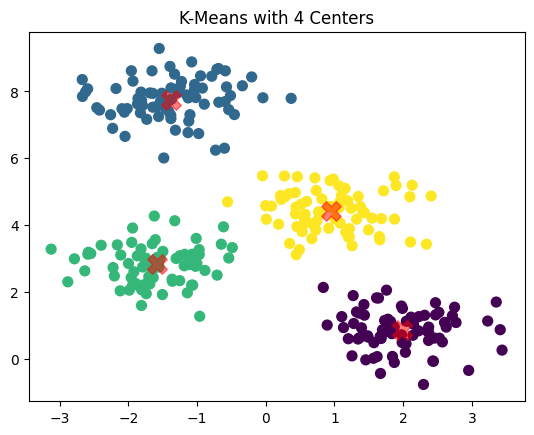

In [2]:
# 21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=4, n_init='auto')
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='X', c='red', alpha=0.5)
plt.title('K-Means with 4 Centers')
plt.show()

In [3]:
# 22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display first 10 labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(iris.data)
print('First 10 labels:', labels[:10])

First 10 labels: [1 1 1 1 1 1 1 1 1 1]


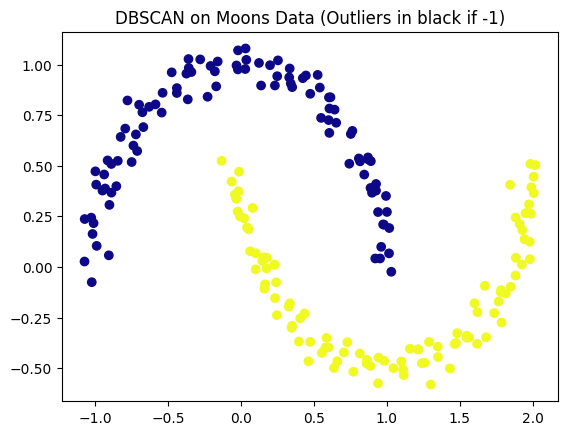

In [4]:
# 23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers.
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=200, noise=0.05, random_state=0)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title('DBSCAN on Moons Data (Outliers in black if -1)')
plt.show()

In [5]:
# 24. Load the Wine dataset, apply K-Means after standardizing. Print cluster sizes.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels = kmeans.fit_predict(X)
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


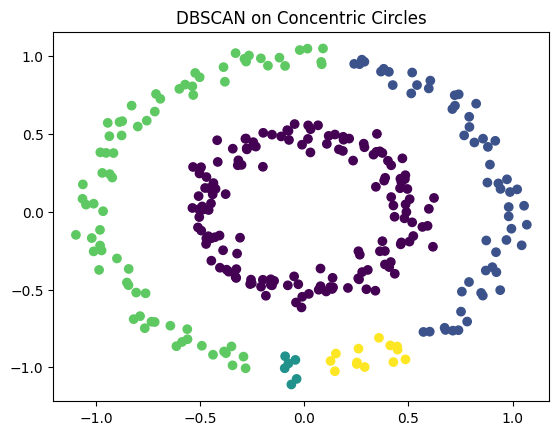

In [6]:
# 25. Use make_circles and cluster it using DBSCAN.
from sklearn.datasets import make_circles
X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
db = DBSCAN(eps=0.15, min_samples=5)
plt.scatter(X[:, 0], X[:, 1], c=db.fit_predict(X))
plt.title('DBSCAN on Concentric Circles')
plt.show()

In [7]:
# 26. Load Breast Cancer, apply MinMaxScaler, use K-Means (2 clusters). Output centroids.
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
data = load_breast_cancer()
X = MinMaxScaler().fit_transform(data.data)
km = KMeans(n_clusters=2, n_init='auto', random_state=0).fit(X)
print('Cluster Centroids shape:', km.cluster_centers_.shape)
print(km.cluster_centers_)

Cluster Centroids shape: (2, 30)
[[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


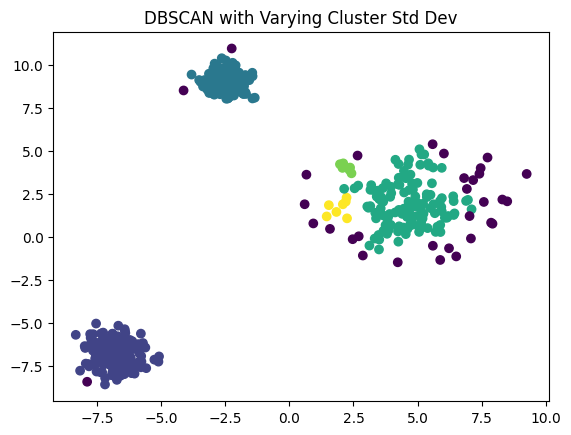

In [8]:
# 27. make_blobs with varying std dev and cluster with DBSCAN.
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=[0.5, 1.5, 0.7], random_state=42)
db = DBSCAN(eps=0.6, min_samples=5)
plt.scatter(X[:, 0], X[:, 1], c=db.fit_predict(X))
plt.title('DBSCAN with Varying Cluster Std Dev')
plt.show()

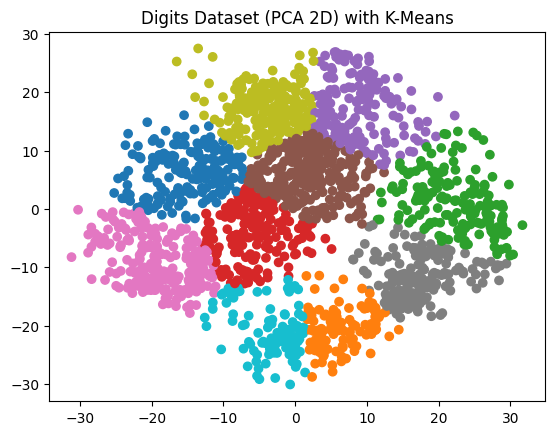

In [9]:
# 28. Load Digits, reduce to 2D using PCA, visualize KMeans clusters.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
digits = load_digits()
X_pca = PCA(n_components=2).fit_transform(digits.data)
km = KMeans(n_clusters=10, n_init='auto', random_state=0)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km.fit_predict(X_pca), cmap='tab10')
plt.title('Digits Dataset (PCA 2D) with K-Means')
plt.show()

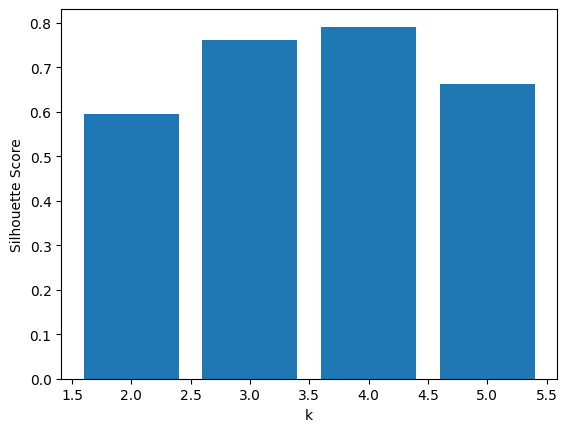

In [10]:
# 29. make_blobs, evaluate silhouette scores for k=2 to 5. Bar chart.
from sklearn.metrics import silhouette_score
X, _ = make_blobs(n_samples=500, centers=4, random_state=42)
scores = [silhouette_score(X, KMeans(n_clusters=k, n_init='auto').fit_predict(X)) for k in range(2, 6)]
plt.bar(range(2, 6), scores)
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

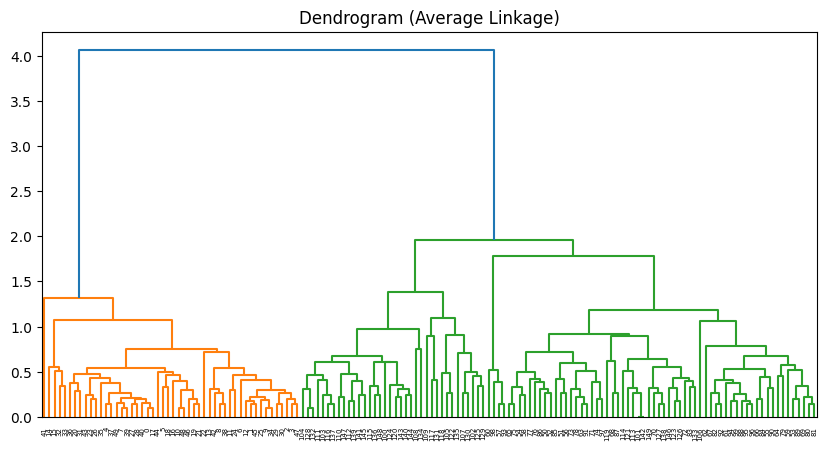

In [11]:
# 30. Iris dataset, hierarchical clustering, dendrogram with average linkage.
from scipy.cluster.hierarchy import dendrogram, linkage
iris = load_iris()
Z = linkage(iris.data, 'average')
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram (Average Linkage)')
plt.show()

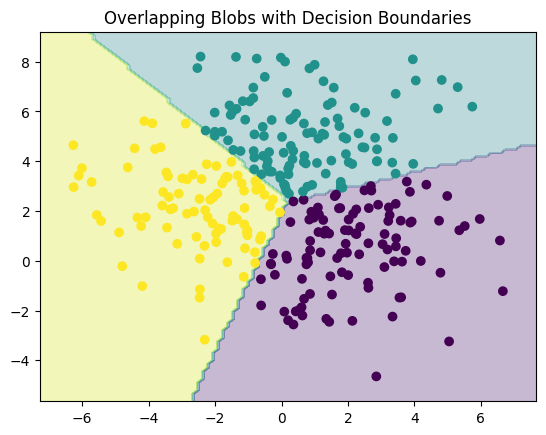

In [12]:
# 31. make_blobs with overlapping clusters, KMeans with decision boundaries.
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=0)
km = KMeans(n_clusters=3, n_init='auto').fit(X)
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100), np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100))
Z = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=km.labels_)
plt.title('Overlapping Blobs with Decision Boundaries')
plt.show()

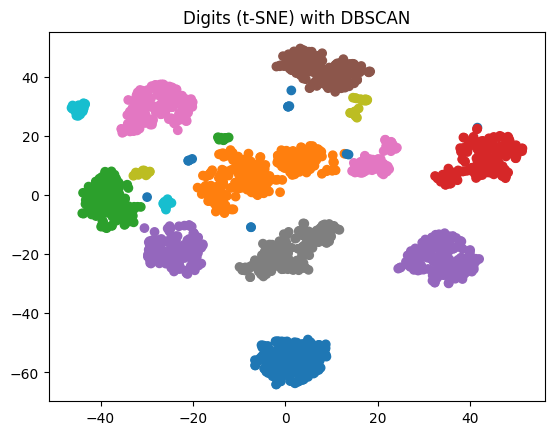

In [13]:
# 32. Digits dataset, DBSCAN after t-SNE reduction.
from sklearn.manifold import TSNE
digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(digits.data)
db = DBSCAN(eps=3.0, min_samples=5)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=db.fit_predict(X_tsne), cmap='tab10')
plt.title('Digits (t-SNE) with DBSCAN')
plt.show()

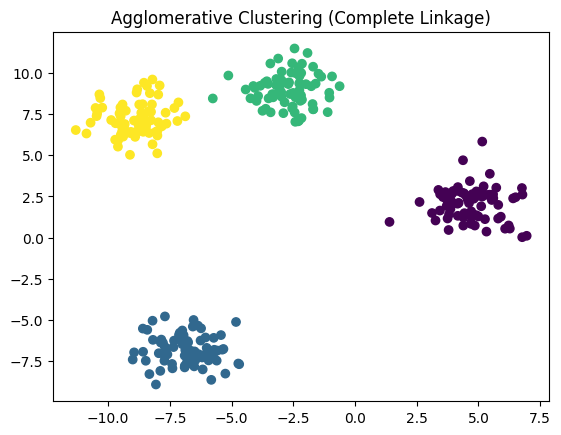

In [14]:
# 33. make_blobs, Agglomerative Clustering with complete linkage.
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)
agg = AgglomerativeClustering(n_clusters=4, linkage='complete')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X))
plt.title('Agglomerative Clustering (Complete Linkage)')
plt.show()

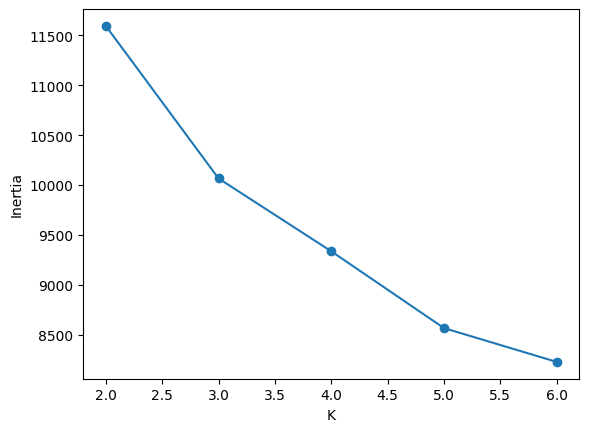

In [15]:
# 34. Breast Cancer dataset, inertia values for K=2 to 6. Line plot.
data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
inertia = [KMeans(n_clusters=k, n_init='auto', random_state=0).fit(X).inertia_ for k in range(2, 7)]
plt.plot(range(2, 7), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

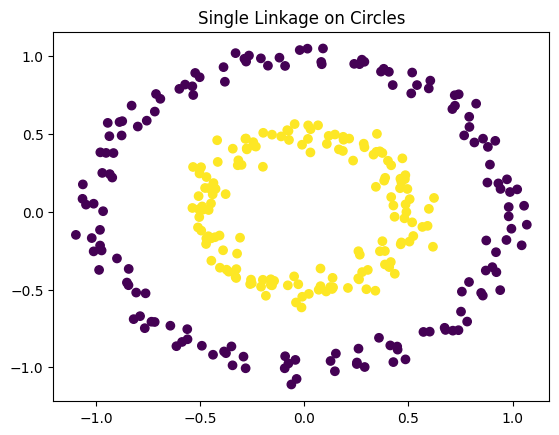

In [16]:
# 35. make_circles, Agglomerative Clustering with single linkage.
X, _ = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X))
plt.title('Single Linkage on Circles')
plt.show()

In [17]:
# 36. Wine dataset, DBSCAN after scaling, count clusters.
X = StandardScaler().fit_transform(wine.data)
db = DBSCAN(eps=2.5, min_samples=5).fit(X)
n_clusters_ = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print('Number of clusters:', n_clusters_)

Number of clusters: 1


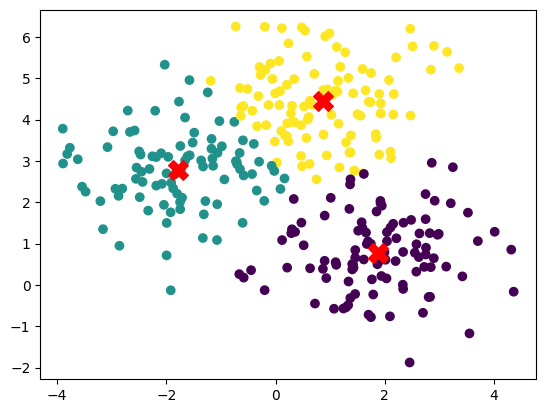

In [18]:
# 37. make_blobs, KMeans, plot cluster centers.
X, _ = make_blobs(n_samples=300, centers=3, random_state=0)
km = KMeans(n_clusters=3, n_init='auto').fit(X)
plt.scatter(X[:, 0], X[:, 1], c=km.labels_)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=200, marker='X', c='red')
plt.show()

In [19]:
# 38. Iris dataset, cluster with DBSCAN, print noise samples.
iris = load_iris()
db = DBSCAN(eps=0.5, min_samples=5).fit(iris.data)
print('Noise points:', list(db.labels_).count(-1))

Noise points: 17


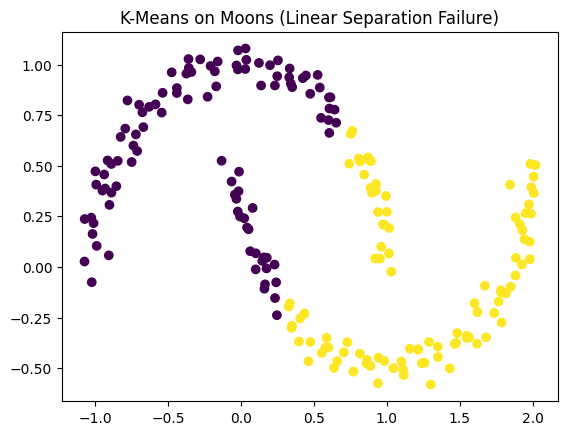

In [20]:
# 39. make_moons, K-Means, visualize results.
X, _ = make_moons(n_samples=200, noise=0.05, random_state=0)
km = KMeans(n_clusters=2, n_init='auto').fit(X)
plt.scatter(X[:, 0], X[:, 1], c=km.labels_)
plt.title('K-Means on Moons (Linear Separation Failure)')
plt.show()

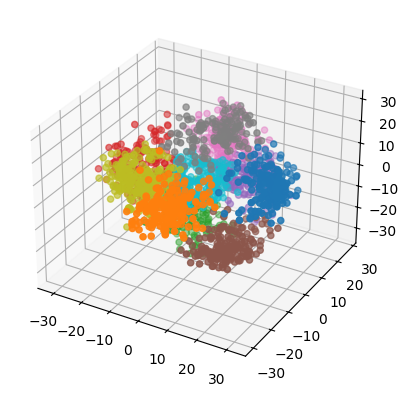

In [21]:
# 40. Digits dataset, PCA to 3 components, KMeans, 3D scatter plot.
from mpl_toolkits.mplot3d import Axes3D
X_pca = PCA(n_components=3).fit_transform(digits.data)
km = KMeans(n_clusters=10, n_init='auto').fit(X_pca)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=km.labels_, cmap='tab10')
plt.show()

In [22]:
# 41. blobs with 5 centers, KMeans, silhouette_score evaluation.
X, _ = make_blobs(n_samples=500, centers=5, random_state=42)
km = KMeans(n_clusters=5, n_init='auto').fit(X)
print('Silhouette Score:', silhouette_score(X, km.labels_))

Silhouette Score: 0.678738720085253


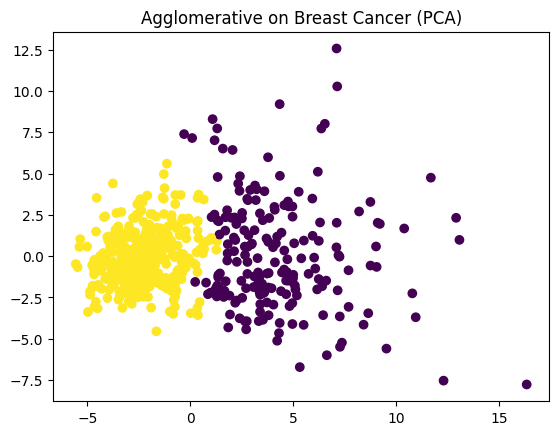

In [23]:
# 42. Breast Cancer, PCA reduction, Agglomerative Clustering visualization.
data = load_breast_cancer()
X_pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(data.data))
agg = AgglomerativeClustering(n_clusters=2).fit_predict(X_pca)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg)
plt.title('Agglomerative on Breast Cancer (PCA)')
plt.show()

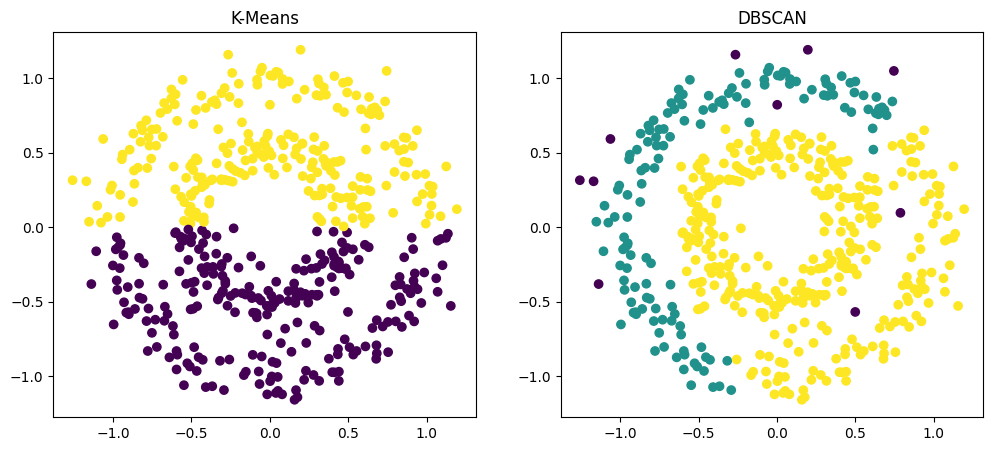

In [24]:
# 43. Noisy circular data, KMeans vs DBSCAN side-by-side.
X, _ = make_circles(n_samples=500, factor=0.5, noise=0.1, random_state=0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X[:, 0], X[:, 1], c=KMeans(n_clusters=2, n_init='auto').fit_predict(X))
ax1.set_title('K-Means')
ax2.scatter(X[:, 0], X[:, 1], c=DBSCAN(eps=0.15, min_samples=5).fit_predict(X))
ax2.set_title('DBSCAN')
plt.show()

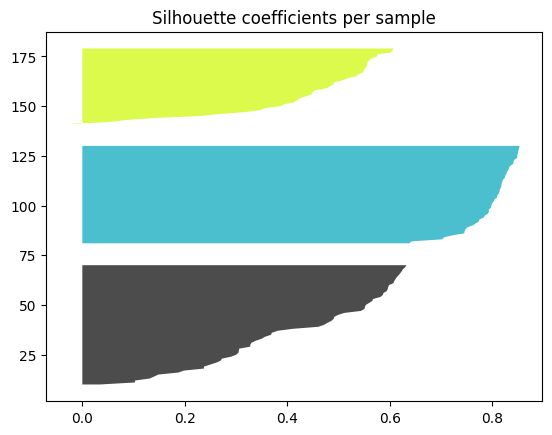

In [25]:
# 44. Iris dataset, Silhouette Coefficient per sample plot.
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
iris = load_iris()
X = iris.data
n_clusters = 3
km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=0)
labels = km.fit_predict(X)
val = silhouette_samples(X, labels)
y_lower = 10
for i in range(n_clusters):
    ith_val = val[labels == i]
    ith_val.sort()
    size_i = ith_val.shape[0]
    y_upper = y_lower + size_i
    color = cm.nipy_spectral(float(i) / n_clusters)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_val, facecolor=color, alpha=0.7)
    y_lower = y_upper + 10
plt.title('Silhouette coefficients per sample')
plt.show()

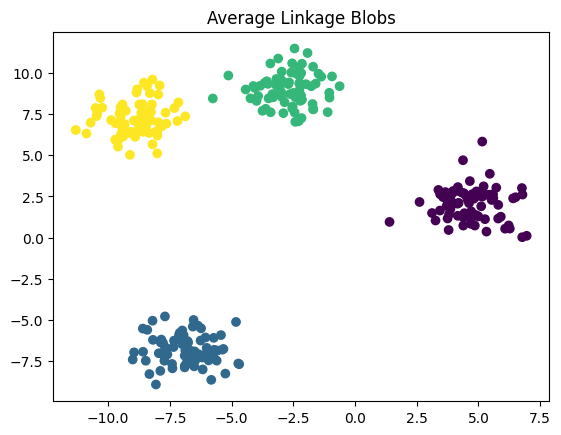

In [26]:
# 45. make_blobs, Agglomerative Clustering with 'average' linkage.
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X))
plt.title('Average Linkage Blobs')
plt.show()

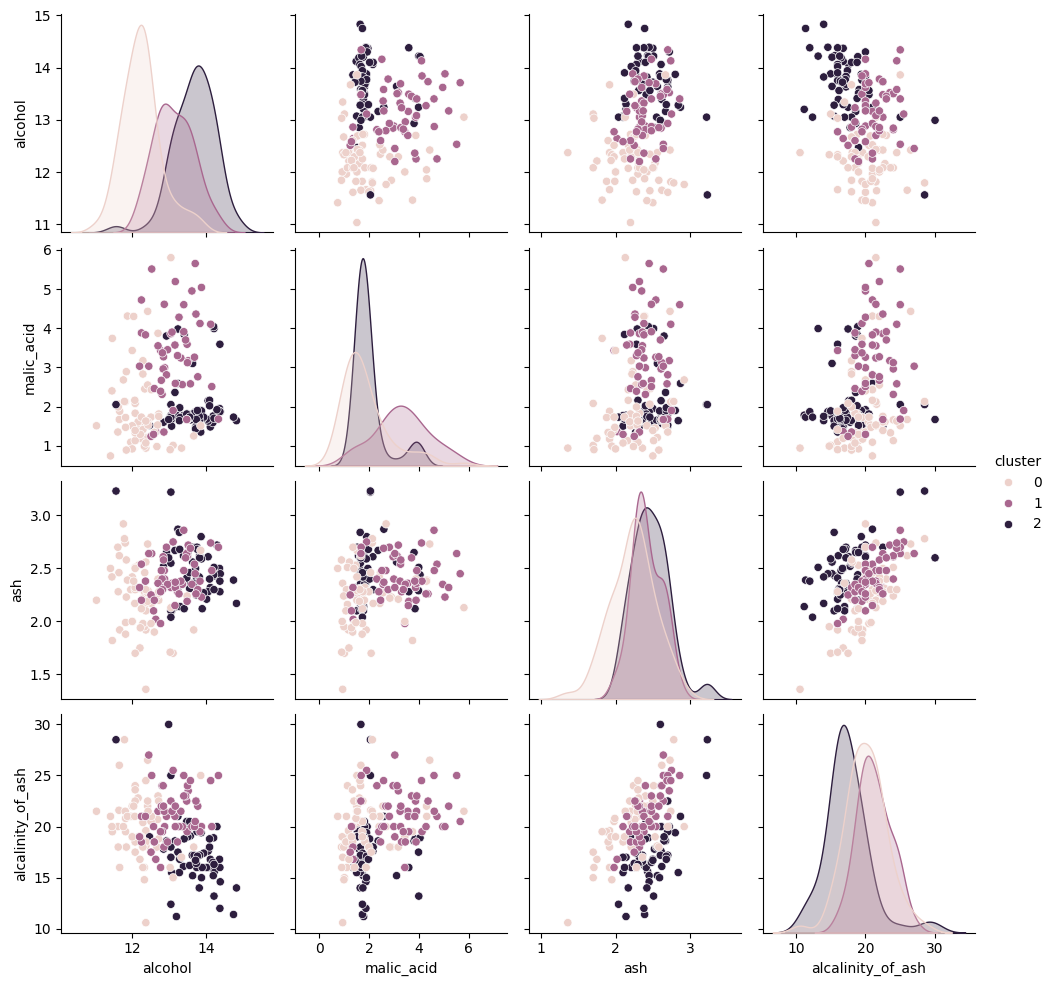

In [27]:
# 46. Wine dataset, KMeans, seaborn pairplot (first 4 features).
import seaborn as sns
import pandas as pd
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
km = KMeans(n_clusters=3, n_init='auto', random_state=0)
wine_df['cluster'] = km.fit_predict(StandardScaler().fit_transform(wine.data))
sns.pairplot(wine_df, vars=wine.feature_names[:4], hue='cluster')
plt.show()

In [28]:
# 47. Noisy blobs, DBSCAN to identify clusters and noise. Print counts.
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=0)
db = DBSCAN(eps=0.8, min_samples=5).fit(X)
labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print(f'Clusters: {n_clusters_}, Noise points: {n_noise_}')

Clusters: 2, Noise points: 23


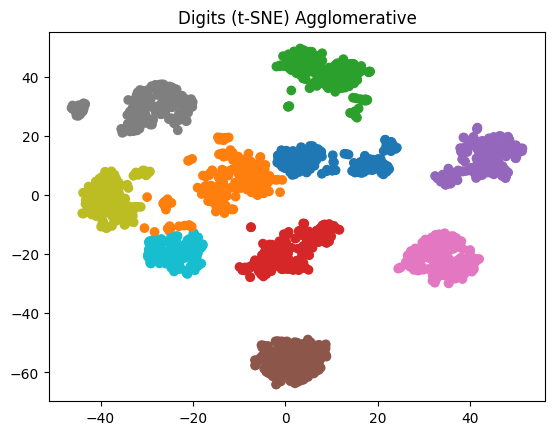

In [29]:
# 48. Digits, t-SNE reduction, Agglomerative Clustering, plot.
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(digits.data)
agg = AgglomerativeClustering(n_clusters=10).fit_predict(X_tsne)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg, cmap='tab10')
plt.title('Digits (t-SNE) Agglomerative')
plt.show()